- From noiseless to DC2 images
- Test of different architecture
- Impact of usage of PSF
- Impact of usage of fft
- First diff on Bayesian neural network

- noisy images

Test are done with sample up to 24.5 magnitude

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

2021-07-07 14:25:45.405324: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


Instructions for updating:
non-resource variables are not supported in the long term


ImportError: libgalsim.so.2.2: cannot open shared object file: No such file or directory

In [5]:
!python -V

Python 3.8.5


## Load data

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

## Load transformations of ellipticities

### for inputs

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

## Load models

### Loading directories

In [3]:
10**(-0.375)

0.4216965034285822

In [1]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v2 = root_dir_models+'v_test_noisy/weights_0_step_150/loss/'#'v14/loss/'  # concat only after all convolution blocks
dir_model_v3 = root_dir_models+'v_no_psf_noisy_256/loss/'#'v15_noisy/bis_bis/mse/'#  # No use of PSF
dir_model_v5 = root_dir_models+'v17_noisy/bis/loss/'#'v17/loss/'  # BNN with concat after all convolution blocks


### Set models parameters

In [5]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

### Define and load models

In [6]:
model_concat_one = model.create_model_wo_ls_peak_pooling_concat_one(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_no_psf = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_bnn = model.create_model_prob_flipout_peak(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0619 14:35:15.185300 140345861572416 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0619 14:35:16.135349 140345861572416 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.
W0619 14:35:17.229469 140345861572416 deprecation.py:323] From ../../scripts/tools_for_VAE/tool

[8192, 256]
Tensor("dense_flipout/Size:0", shape=(), dtype=int32)
[256, 5]
Tensor("dense_flipout_1/Size:0", shape=(), dtype=int32)


In [7]:
latest = tf.train.latest_checkpoint(dir_model_v2)
model_concat_one.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v3)
model_no_psf.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v5)
model_bnn.load_weights(latest)

## Training magnitude cut at 24.5 in $r$-band

### Noiseless images

### Load data 

In [8]:
images = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

#data.replace([np.inf, -np.inf], np.nan, inplace=True)
#data = data.dropna(axis = 0, how = 'any')

new_data=data[(np.abs(data['e1_hsm_regauss'])<=1.) &
         (np.abs(data['e2_hsm_regauss'])<=1.) &
             (data['blendedness']>0)]

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])


ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

data['e1_lensed'] = e1
data['e2_lensed'] = e2

In [11]:
len(e1)

10000

In [12]:
np.max(e1), np.max(e2)

(0.9821383976718834, 0.9535890887826854)

In [47]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7878 entries, 2 to 9998
Data columns (total 14 columns):
id                7878 non-null int64
e1                7878 non-null float64
e2                7878 non-null float64
shear_1           7878 non-null float64
shear_2           7878 non-null float64
redshift          7878 non-null float64
redshift_true     7878 non-null float64
blendedness       7878 non-null float64
snr_r             7878 non-null float64
convergence       7878 non-null float64
e1_hsm_regauss    7878 non-null float64
e2_hsm_regauss    7878 non-null float64
mag_r_meas        7878 non-null float64
mag_r_true        7878 non-null float64
dtypes: float64(13), int64(1)
memory usage: 923.2 KB


In [48]:
nb_of_points = 1000
indices = np.random.choice(new_data.index, size=nb_of_points, replace=False, p = None)

0.9893580675125122

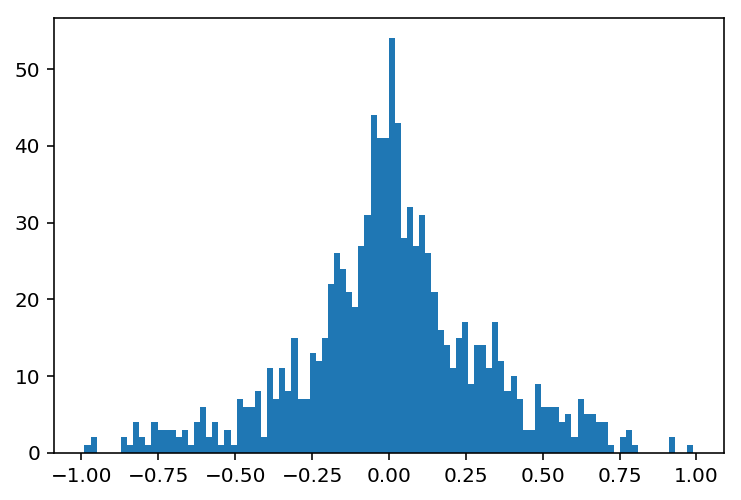

In [12]:
_ = plt.hist(new_data['e1_hsm_regauss'][:1000], bins = 100)
np.max(new_data['e1_hsm_regauss'][:1000])

In [52]:
data_val = pd.read_csv(root_dir_v2+'img_noiseless_data_2.csv')

In [10]:
len(data)#, len(data_val)

10000

## Test of models

In [13]:
nb_of_points = 1000
indices = np.random.choice(new_data.index, size=nb_of_points, replace=False, p = None)

In [11]:
output_v1 = model_no_psf([tf.cast(images[9000:10000], tf.float32), tf.cast(psf[9000:10000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

In [12]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_ell_4.csv')

In [13]:
part_1 = pd.read_csv('data/df_param_ell_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_4.csv', encoding = 'utf-8')

df_plot = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [14]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = df_plot['e1_out_mean']
d['e2'] = df_plot['e2_out_mean']
d['e1_std'] = df_plot['e1_out_std']
d['e2_std'] = df_plot['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss']], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000

In [15]:
df_plot_2 = df[df['blendedness']>0]

In [28]:
import numpy as np
import scipy.stats as stats
import math

mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
#plt.plot(x, stats.norm.pdf(x, mu, sigma))
#plt.show()

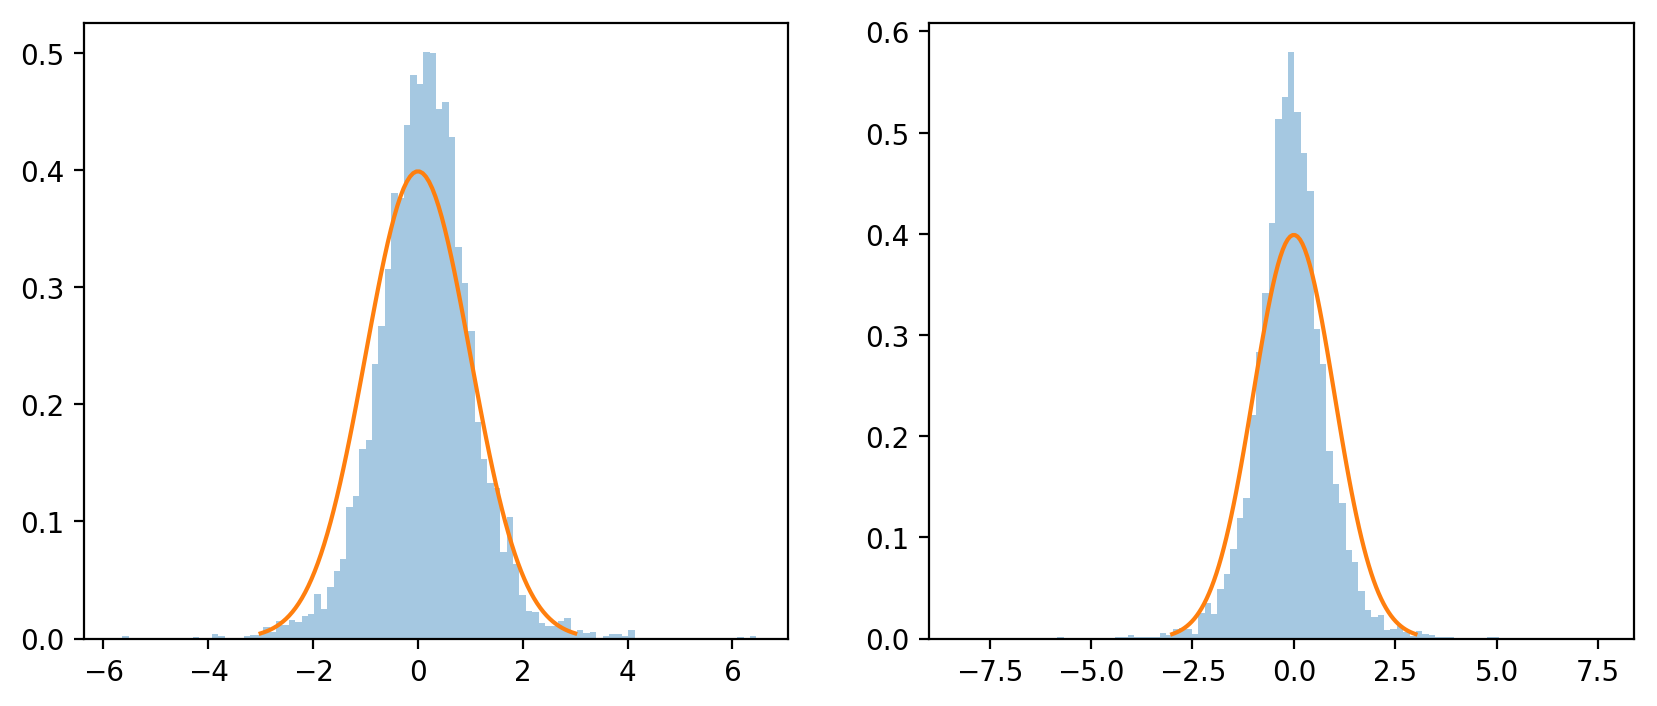

In [35]:
fig, axes = plt.subplots(1,2, figsize =(10,4))

_ = axes[0].hist((d['e1_in']-d['e1'])/d['e1_std'], bins = 100, normed = True, alpha = 0.4)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma))


_ = axes[1].hist((d['e2_in']-d['e2'])/d['e1_std'], bins = 100, normed = True, alpha = 0.4)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma))

16170
[1 2]
0 1
1 2


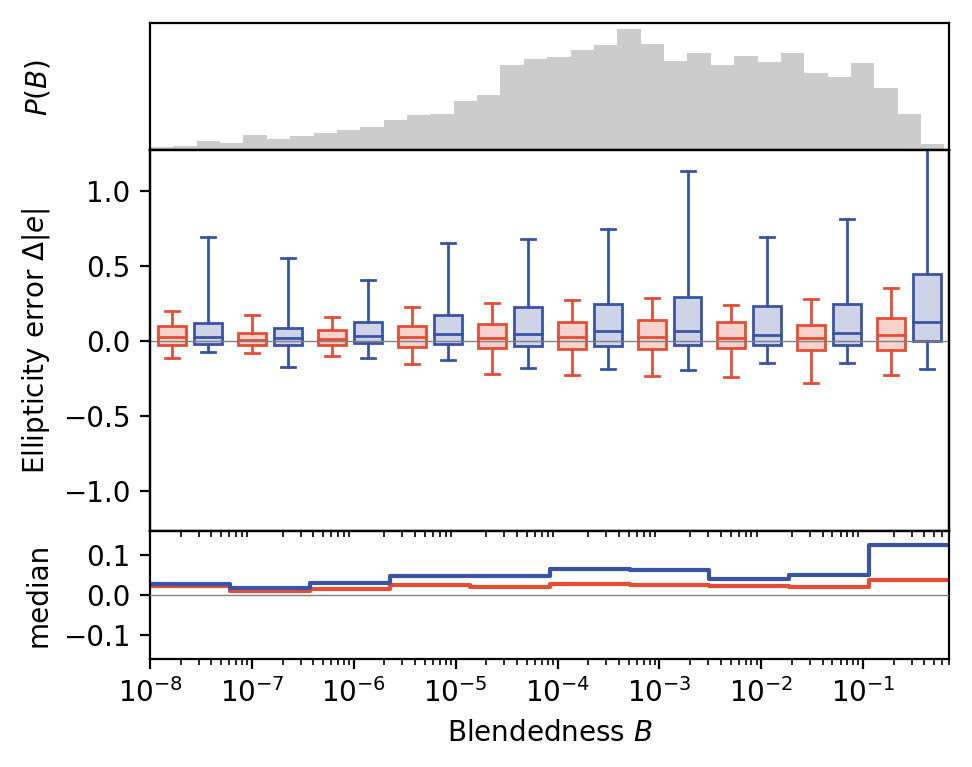

In [23]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

fig.savefig('imgs/e_blend_dc2_ell_hsm.pdf')

In [24]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [25]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,stats_names
0,0.022838,0.025154,0.097262,0.112155,0.196507,network
1,0.008859,0.029799,0.052727,0.079188,0.172103,network
2,0.014150,0.028790,0.070311,0.100123,0.158739,network
3,0.024720,0.042679,0.102105,0.152868,0.225677,network
4,0.019185,0.047105,0.110993,0.218630,0.254344,network
5,0.027919,0.055444,0.122832,0.225795,0.270531,network
6,0.025145,0.056030,0.138666,0.232883,0.287447,network
7,0.022429,0.045863,0.123322,0.241827,0.240842,network
8,0.019209,0.061071,0.108990,0.279308,0.281860,network
9,0.038242,0.062145,0.155819,0.225270,0.351747,network


In [18]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.02226964067495103, 0.051497621612620226]
improvement between each exp: [2.3124585782178753]


19974
[1 2]
0 1
1 2


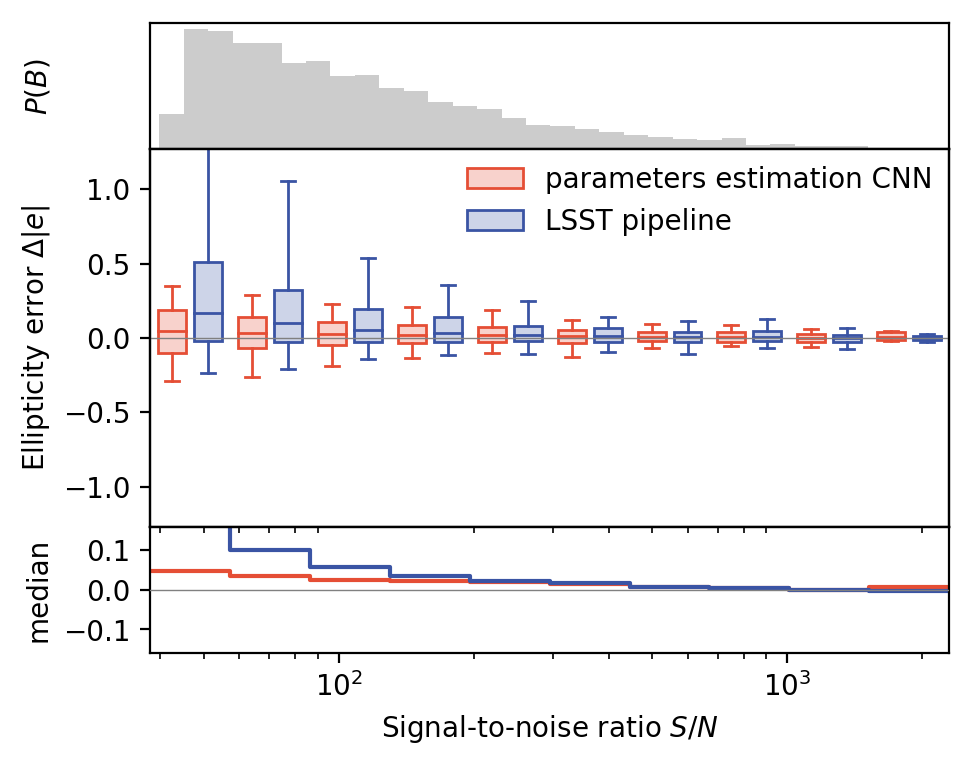

In [19]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['parameters estimation CNN', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

fig.savefig('imgs/e_snr_dc2_ell_hsm.pdf')

In [20]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [21]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.018035472064373077, 0.04118391291670724]
improvement between each exp: [2.2834951461049444]


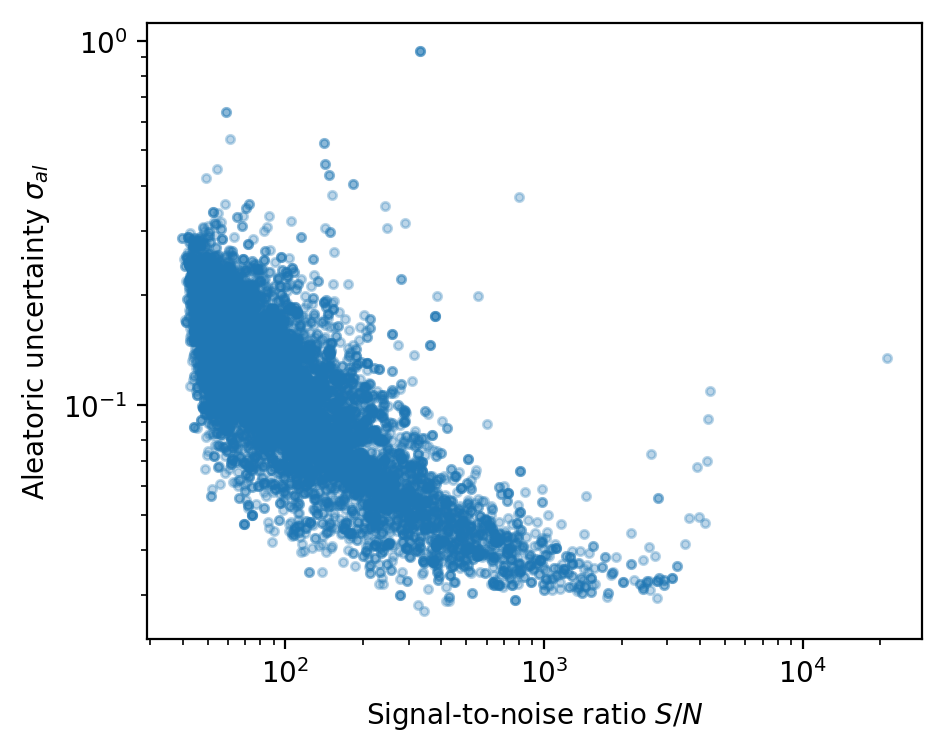

In [22]:
#plt.hist2d(data['snr_r'], d['e1_std'], bins = 10)
fig, axes = plt.subplots(1,1, figsize= (5,4))
axes.plot(data['snr_r'], d['e1_std'], '.', alpha = 0.3)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('Signal-to-noise ratio $S/N$')
axes.set_ylabel('Aleatoric uncertainty $\sigma_{al}$')

fig.savefig('imgs/sigma_al_param_ell.pdf')

Text(0.5, 1.0, '$e2$')

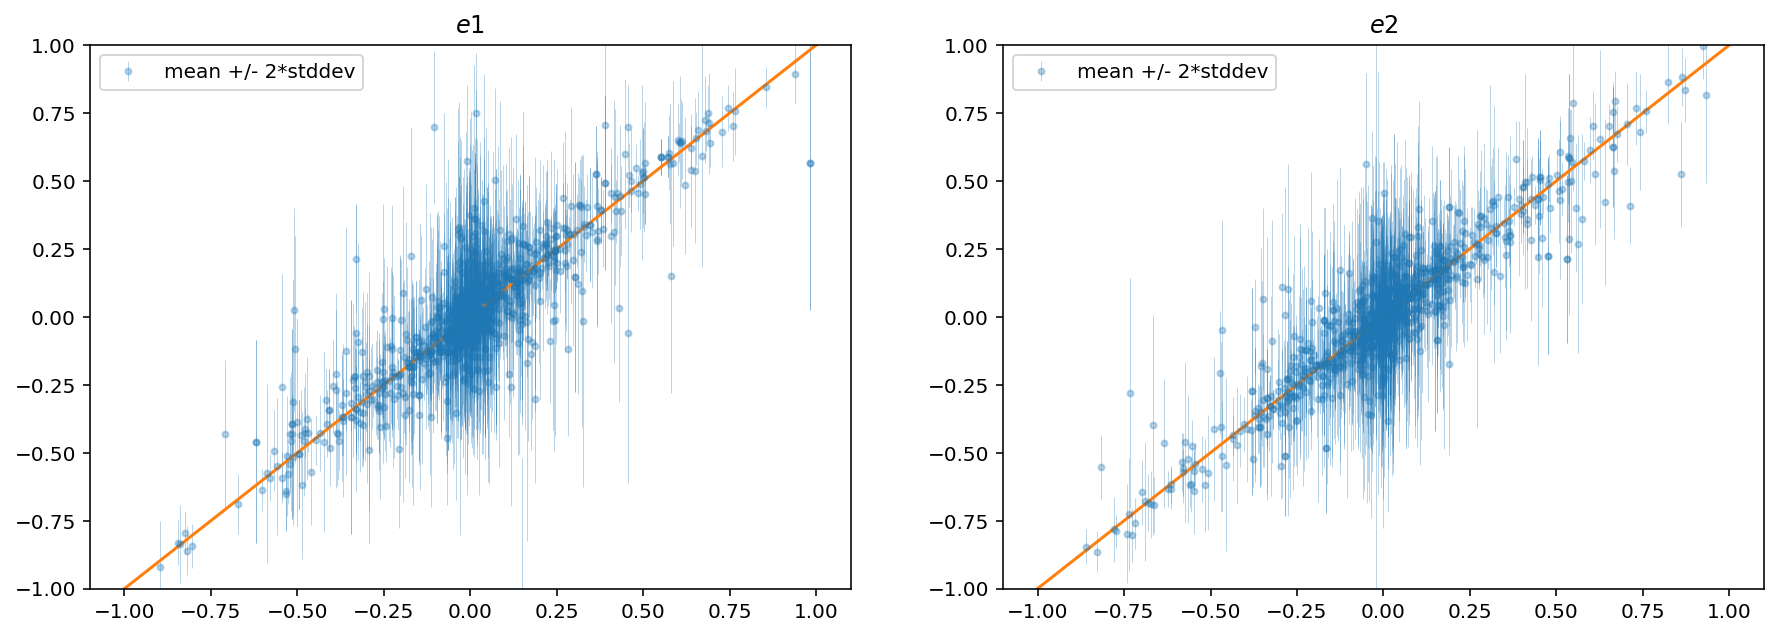

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(data['e1_lensed'][indices], -e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(data['e2_lensed'][indices], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

Text(0.5, 1.0, '$e2$')

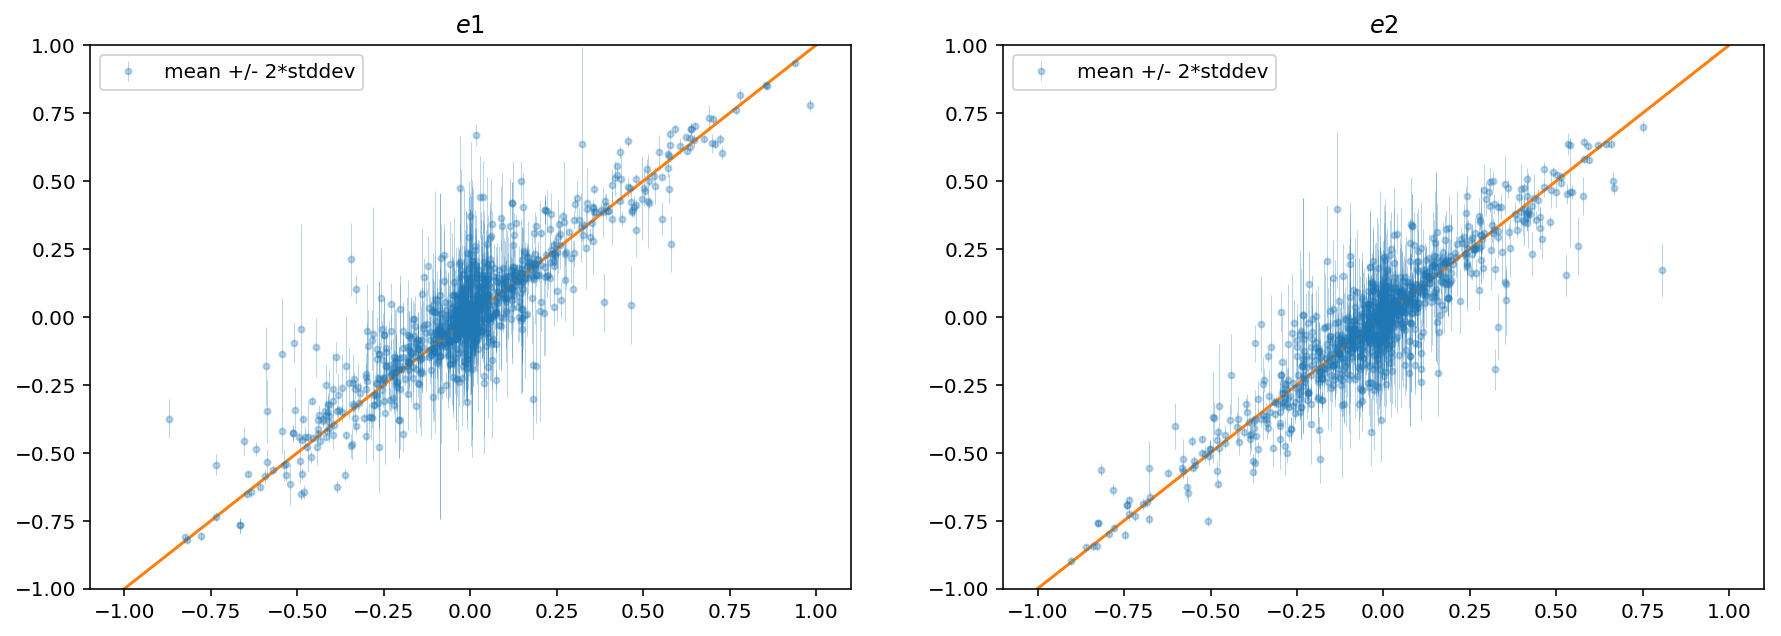

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(data['e1_lensed'][indices], -e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(data['e2_lensed'][indices], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

Text(0.5, 0, '$e_2$ truth')

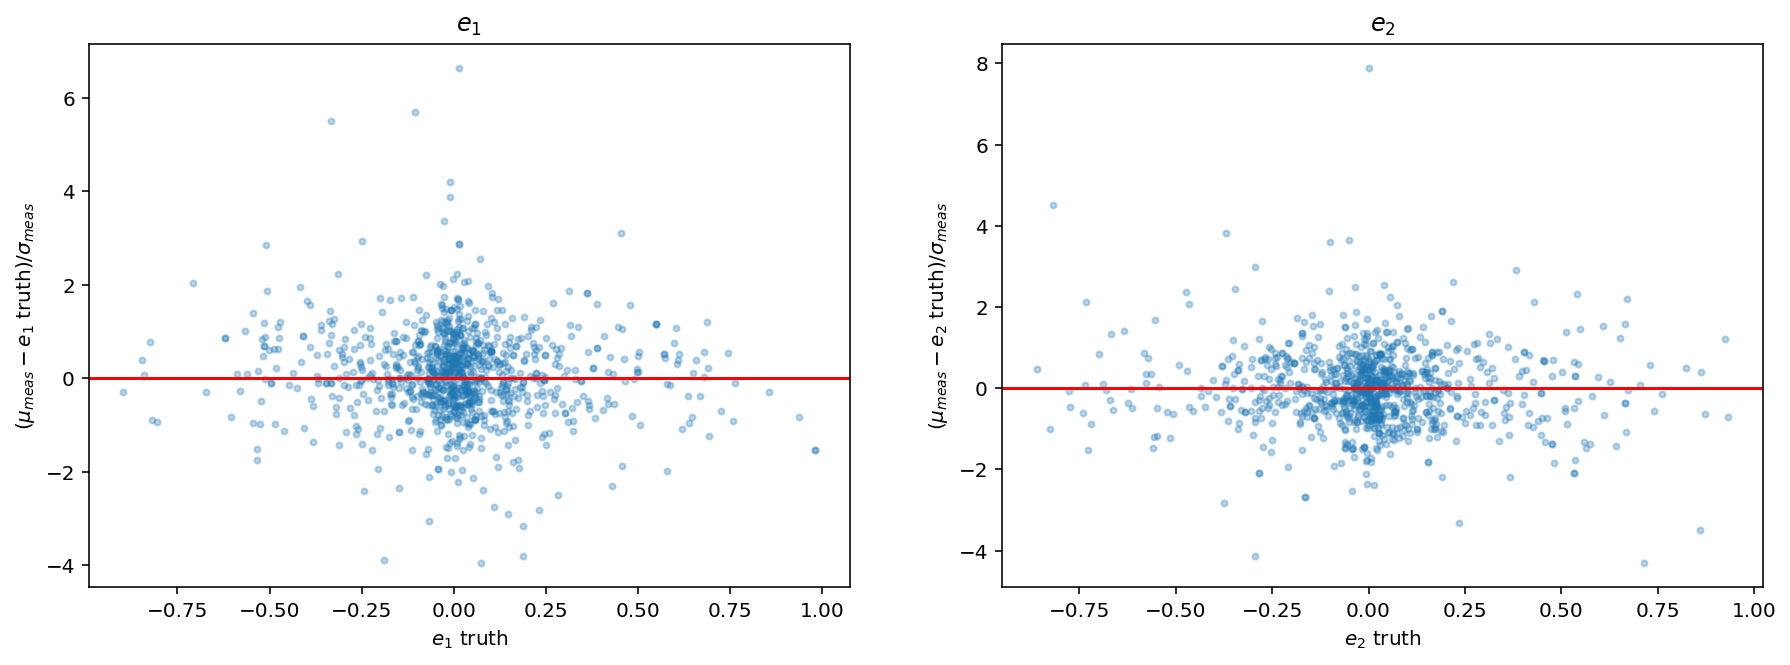

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(data['e1_lensed'][indices], (-e1_out_mean-data['e1_lensed'][indices])/e1_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[0].plot(x, x)
axes[0].axhline(0, color = 'r')
#axes[0].legend()
#axes[0].set_ylim(-1,1)
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('$e_1$ truth')

axes[1].plot(data['e2_lensed'][indices], (e2_out_mean-data['e2_lensed'][indices])/e2_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[1].plot(x, x)
#axes[1].legend()
axes[1].axhline(0, color = 'r')
#axes[1].set_ylim(-1,1)
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')

axes[1].set_xlabel('$e_2$ truth')

Text(0.5, 0, '$e_2$ truth')

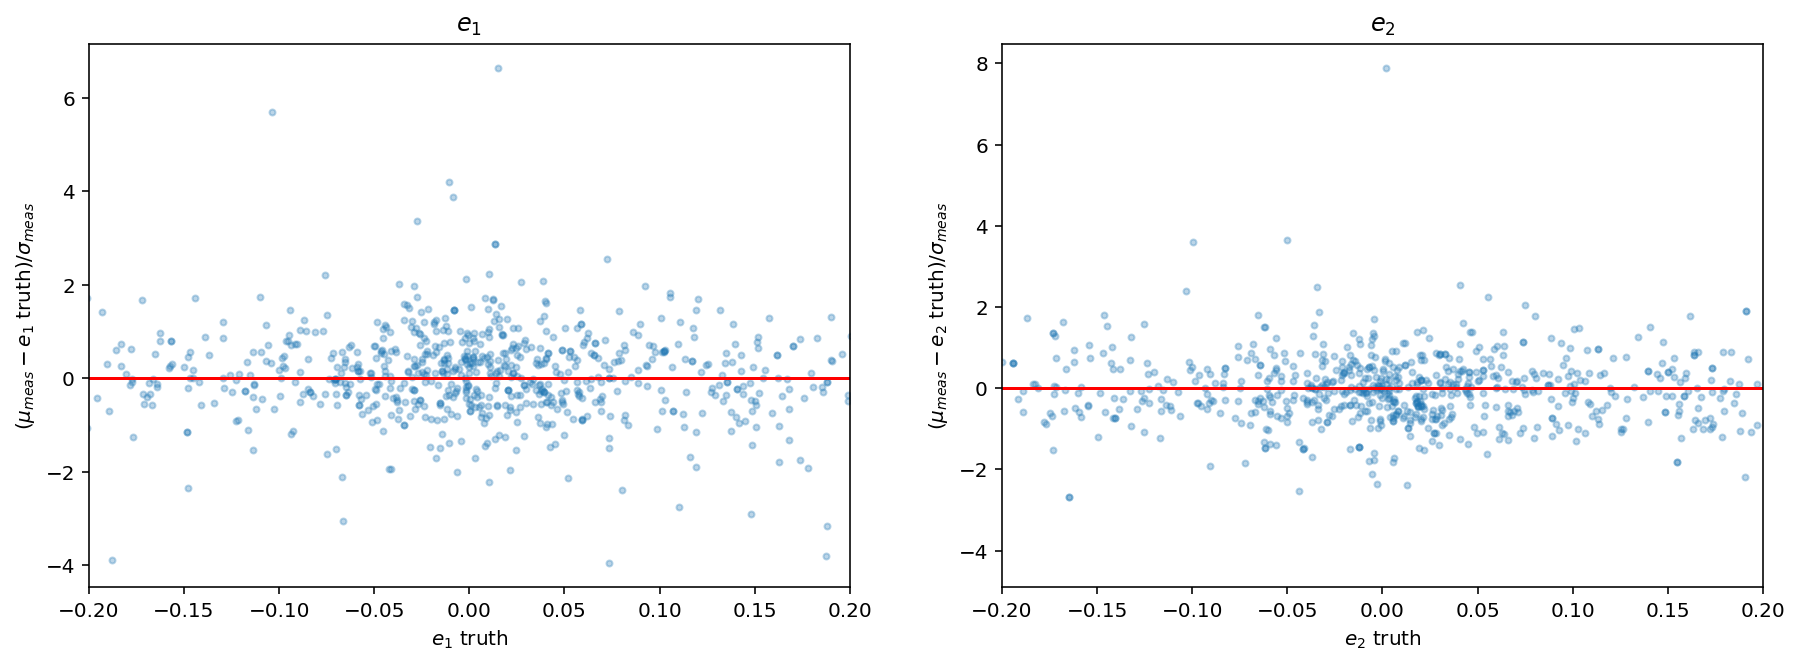

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(data['e1_lensed'][indices], (-e1_out_mean-data['e1_lensed'][indices])/e1_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[0].plot(x, x)
axes[0].axhline(0, color = 'r')
#axes[0].legend()
#axes[0].set_ylim(-1,1)
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('$e_1$ truth')
axes[0].set_xlim(-0.2,0.2)

axes[1].plot(data['e2_lensed'][indices], (e2_out_mean-data['e2_lensed'][indices])/e2_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[1].plot(x, x)
#axes[1].legend()
axes[1].axhline(0, color = 'r')
#axes[1].set_ylim(-1,1)
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')
axes[1].set_xlim(-0.2,0.2)

axes[1].set_xlabel('$e_2$ truth')

Text(0.5, 0, 'Blendedness')

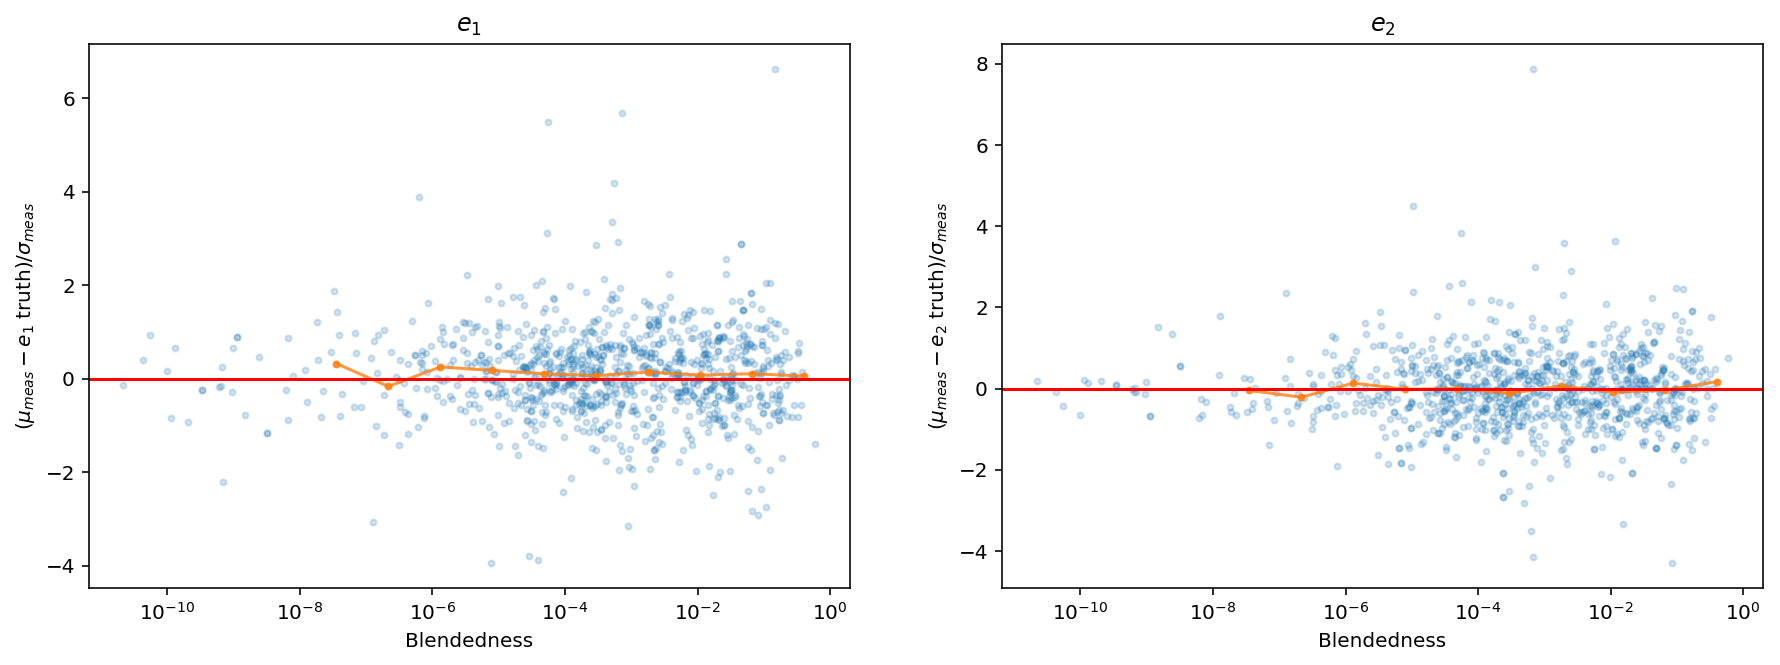

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins=np.geomspace(1e-8, 0.7, 11)
#bins = np.linspace(-11,0,11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (-e1_out_mean-data['e1_lensed'][indices])/e1_out_std, statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[0].plot(data['blendedness'][indices], (-e1_out_mean-data['e1_lensed'][indices])/e1_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')
axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

#bins=np.logspace(np.log10(1e-11),0.7, 11)
bins=np.geomspace(1e-8, 0.7, 11)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-data['e2_lensed'][indices])/e2_out_std, statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[1].plot(data['blendedness'][indices], (e2_out_mean-data['e2_lensed'][indices])/e2_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')
axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')

Text(0.5, 0, 'Blendedness')

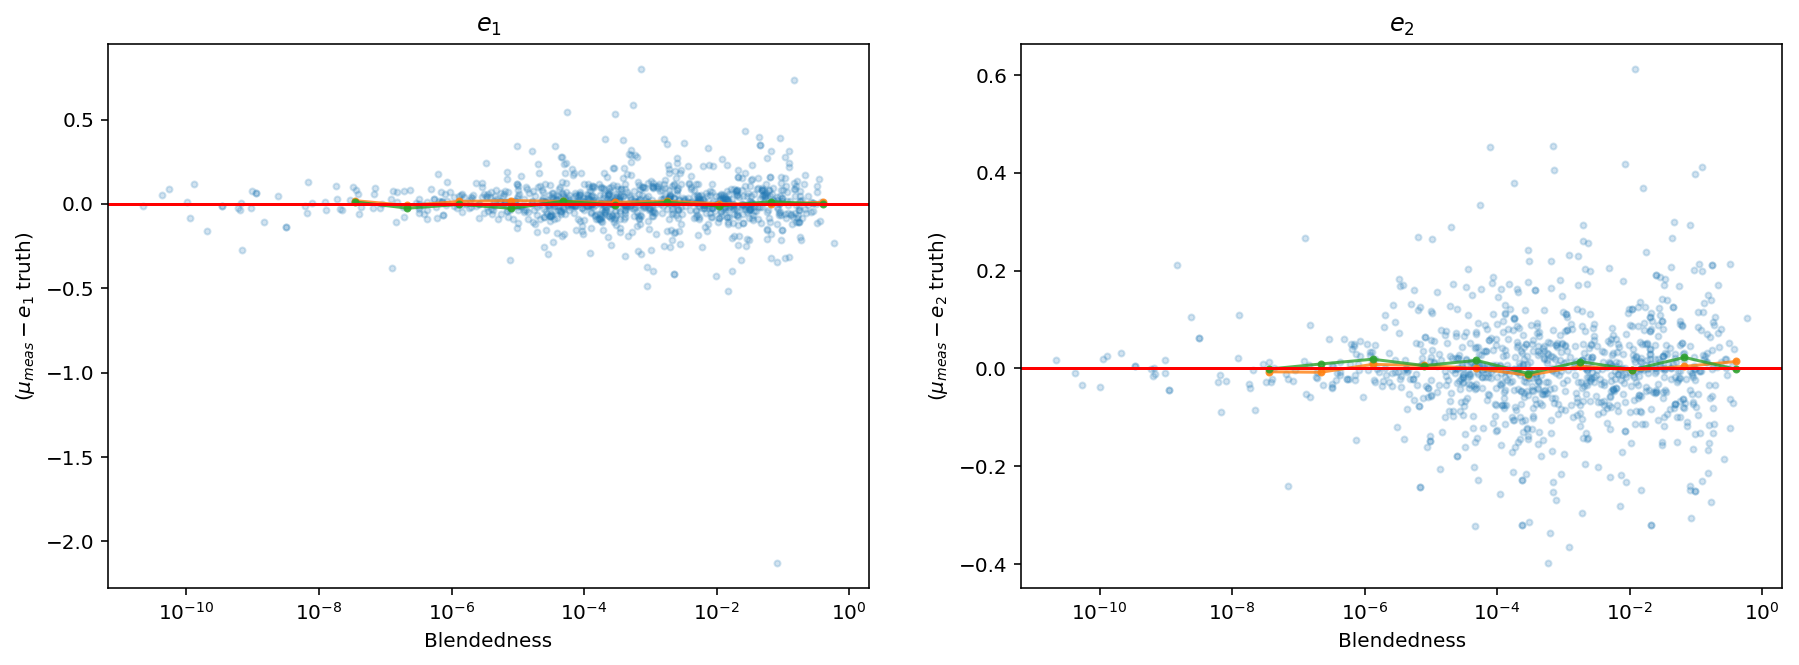

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (-e1_out_mean-data['e1_lensed'][indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[0].plot(data['blendedness'][indices], (-e1_out_mean-data['e1_lensed'][indices]), '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-data['e1_lensed'][indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-data['e2_lensed'][indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[1].plot(data['blendedness'][indices], (e2_out_mean-data['e2_lensed'][indices]), '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-data['e2_lensed'][indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')

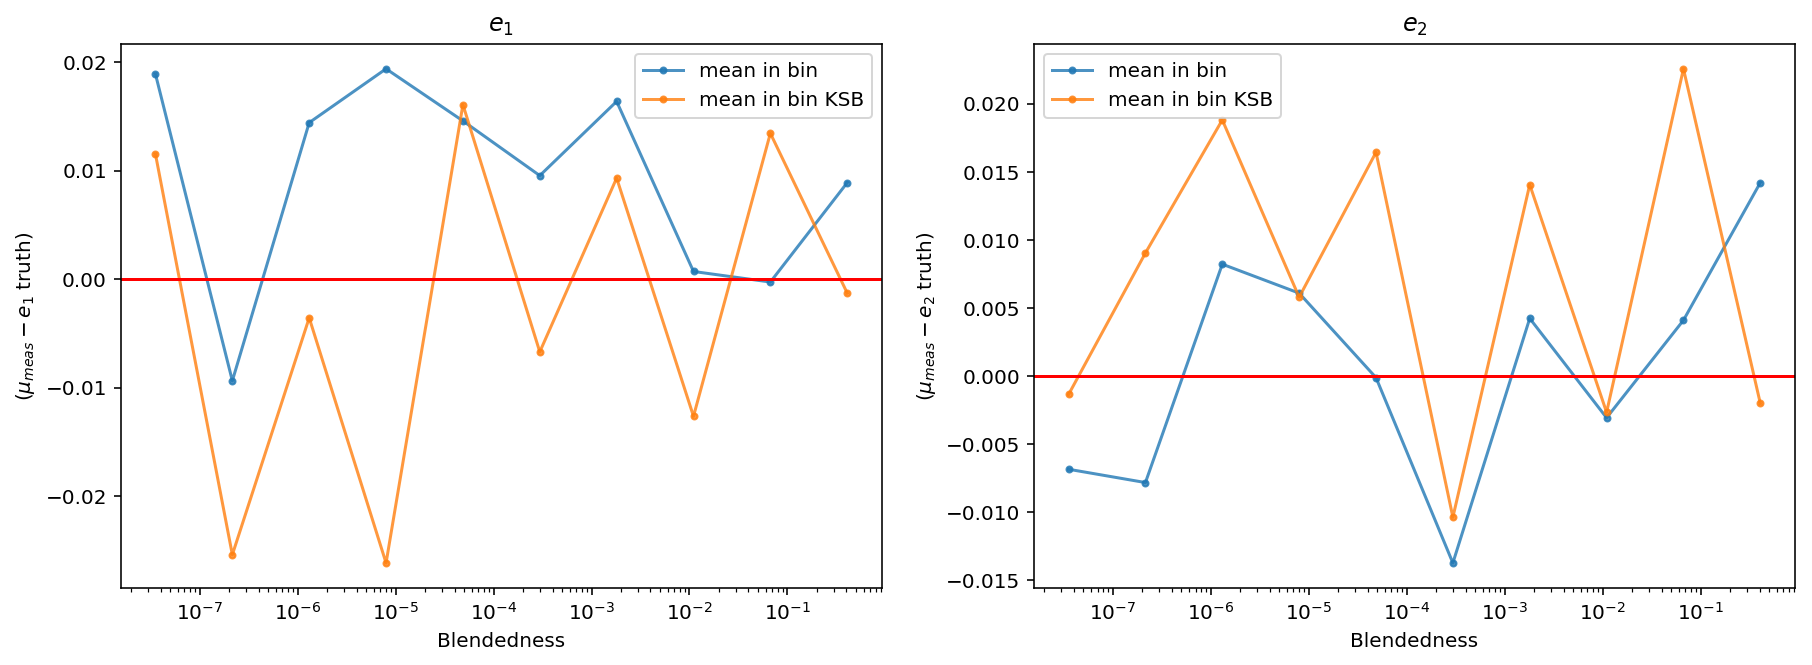

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (-e1_out_mean-e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
axes[0].legend()

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[1].legend()

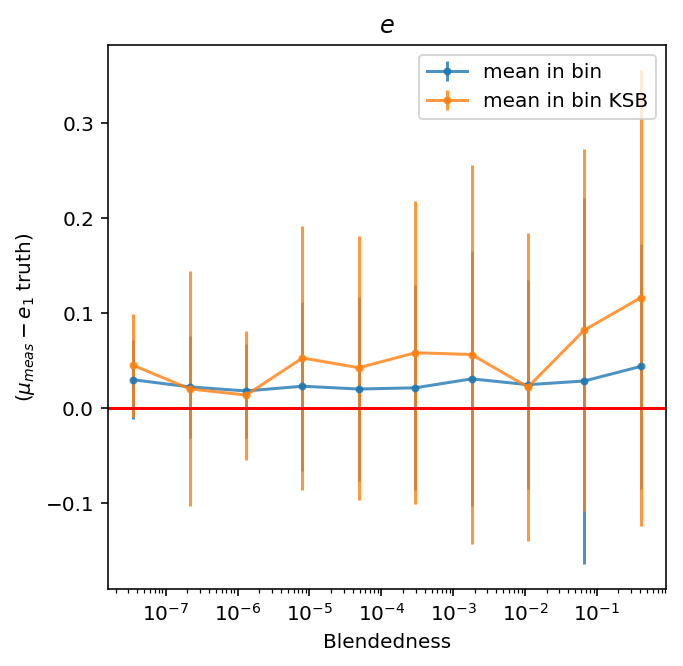

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))


e_meas = np.sqrt(np.square(e1_out_mean)+np.square(e2_out_mean))
e = np.sqrt(np.square(e1[indices])+np.square(e2[indices]))
e_hsm = np.sqrt(np.square(data['e1_hsm_regauss'][indices])+np.square(data['e2_hsm_regauss'][indices]))

#bins=np.logspace(np.log10(1e-9),0.7, 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e_meas-e), statistic='median', bins=bins)
bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e_meas-e), statistic='std', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean +/- 2*stddev', alpha = 0.2)
axes.errorbar(bin_centers,bin_means,yerr =bin_std , marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')

#bins=np.logspace(np.log10(1e-11),np.log10(1), 11)
bins=np.geomspace(1e-8, 0.7, 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e_hsm-e), statistic='median', bins=bins)
bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e_hsm-e), statistic='std', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes.errorbar(bin_centers,bin_means,yerr =bin_std , marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes.axhline(0, color = 'r')
axes.set_title('$e$')
axes.set_ylabel('($\mu_{meas} - e_1$ truth)')
axes.set_xlabel('Blendedness')
axes.set_xscale('log')
axes.legend()


In [22]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = -e1_out_mean
d['e2'] = e2_out_mean
d['e1_std'] = e1_out_std
d['e2_std'] = e2_out_std
d['e1_in'] = e1[indices]#data['e1_lensed'][indices]
d['e2_in'] = e2[indices]#data['e2_lensed'][indices]
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss'][indices]], ignore_index = True)#, ignore_index=True, sort = True)
df['e_1_in'] = pd.concat([d['e1_in'],d['e1_in']], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss'][indices]], ignore_index = True)
df['e_2_in'] = pd.concat([d['e2_in'],d['e2_in']], ignore_index = True)#, ignore_index=True, sort = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss'][indices]**2+data['e2_hsm_regauss'][indices]**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
df['e1_error_reg'] = df['e_1']-df['e_1_in']
df['e2_error_reg'] = df['e_2']-df['e_2_in']
df['e1_std']=pd.concat([d['e1_std'],d['e1_std']], ignore_index = True)
df['e2_std']=pd.concat([d['e2_std'],d['e2_std']], ignore_index = True)
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'][indices],data['blendedness'][indices]], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'][indices],data['snr_r'][indices]], ignore_index = True)

df['exp'] = [1]*1000+[2]*1000

In [23]:
df_plot_2 = df[df['blendedness']>0]

2000
[1 2]
0 1
1 2


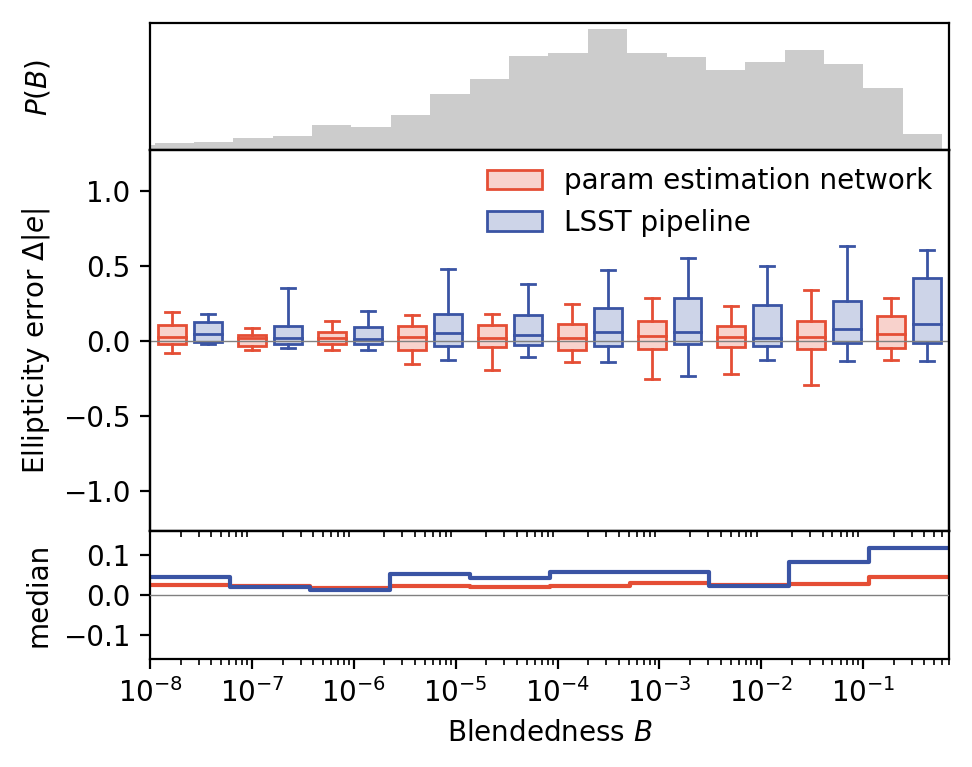

In [24]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_hsm.pdf')

In [25]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [26]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,stats_names
0,0.024841,0.021233,0.106074,0.079576,0.194261,network
1,0.022202,0.036822,0.037801,0.059607,0.089256,network
2,0.017928,0.017490,0.056293,0.062241,0.130034,network
3,0.022921,0.060331,0.100365,0.156083,0.172039,network
4,0.019965,0.039922,0.107560,0.194955,0.177367,network
5,0.021227,0.057660,0.115311,0.140593,0.245322,network
6,0.030647,0.055626,0.136079,0.252971,0.286772,network
7,0.024552,0.037403,0.100724,0.217383,0.230534,network
8,0.028418,0.050970,0.132375,0.294886,0.337767,network
9,0.043748,0.045839,0.167812,0.123927,0.287556,network


In [27]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.025644772970926773, 0.05079865149967221]
improvement between each exp: [1.9808579142916234]


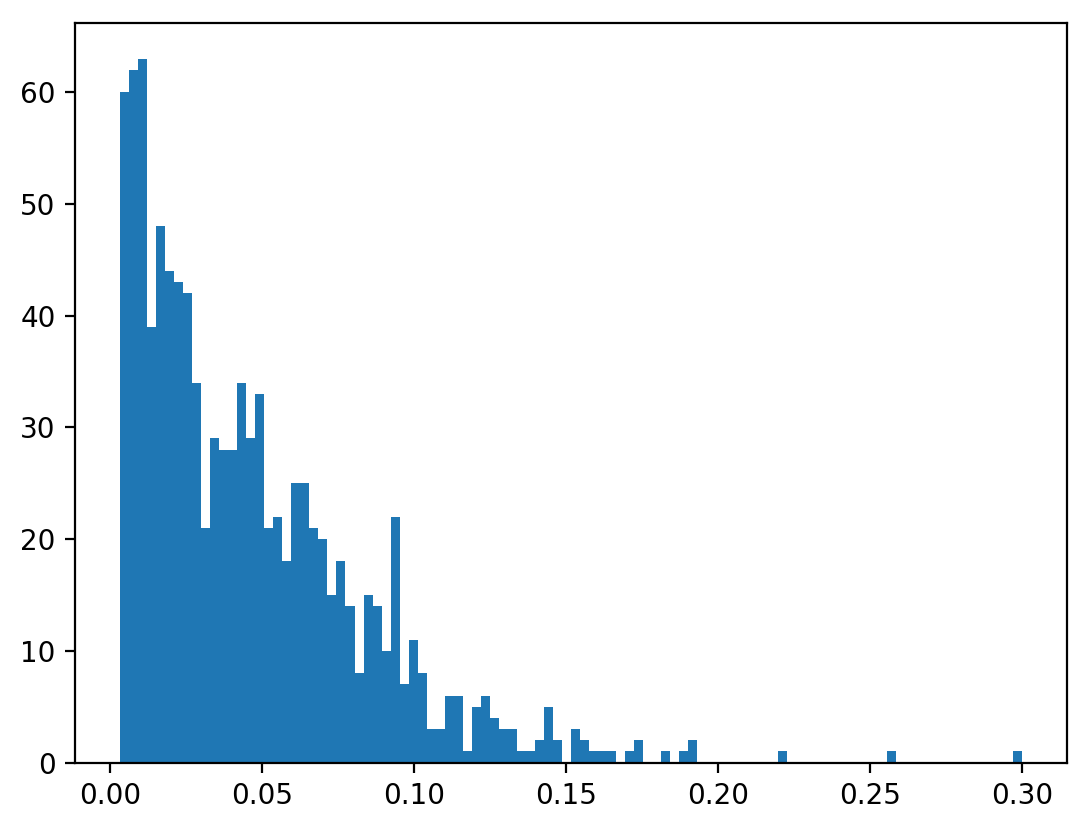

In [67]:
_ = plt.hist(d['e1_std'], bins = 100)

In [22]:
df_plot_3 = df[df['e1_std']<0.15]

2000
[1 2]
0 1
1 2


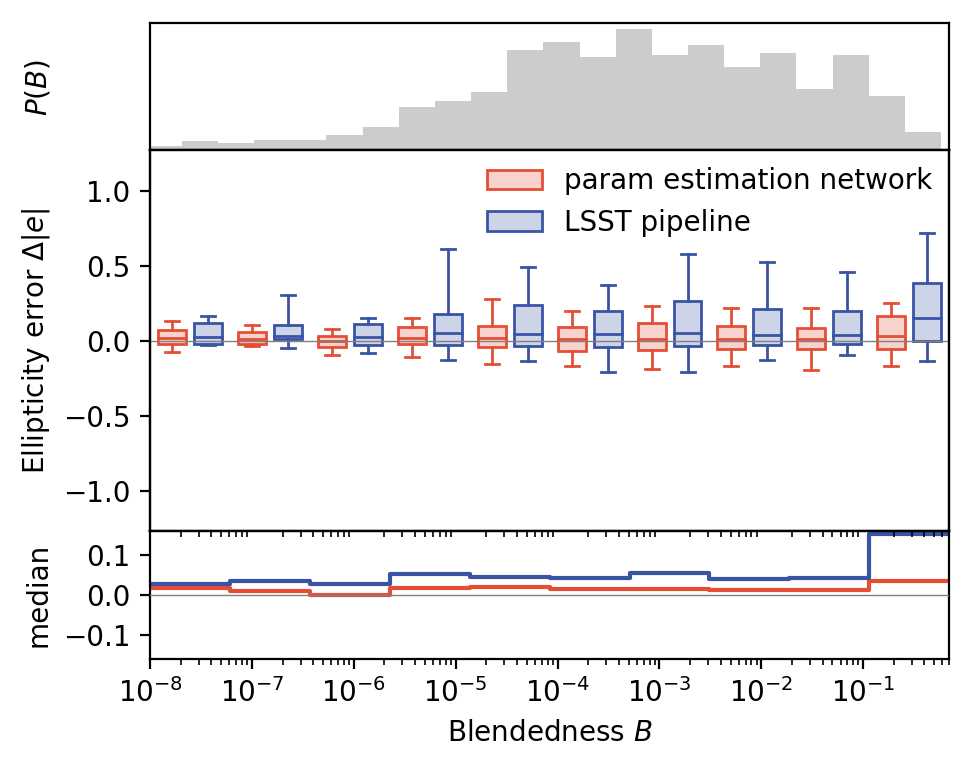

In [23]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_hsm.pdf')

6000
[1 2]
0 1
1 2


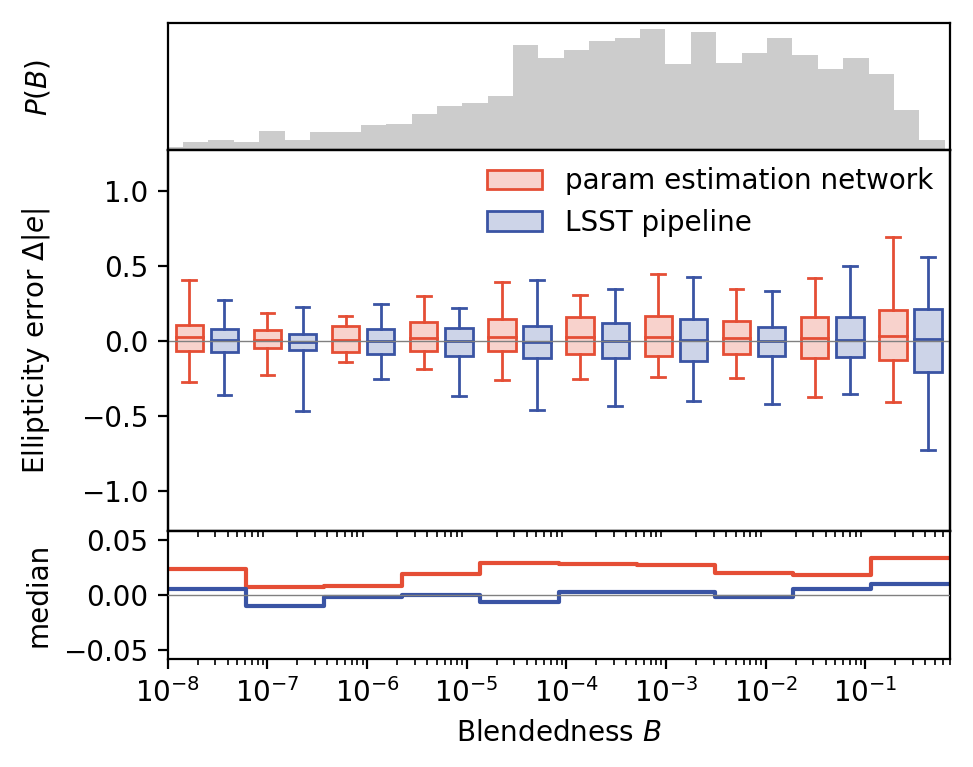

In [25]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e1_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.058, 0.058),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_hsm.pdf')

6000
[1 2]
0 1
1 2


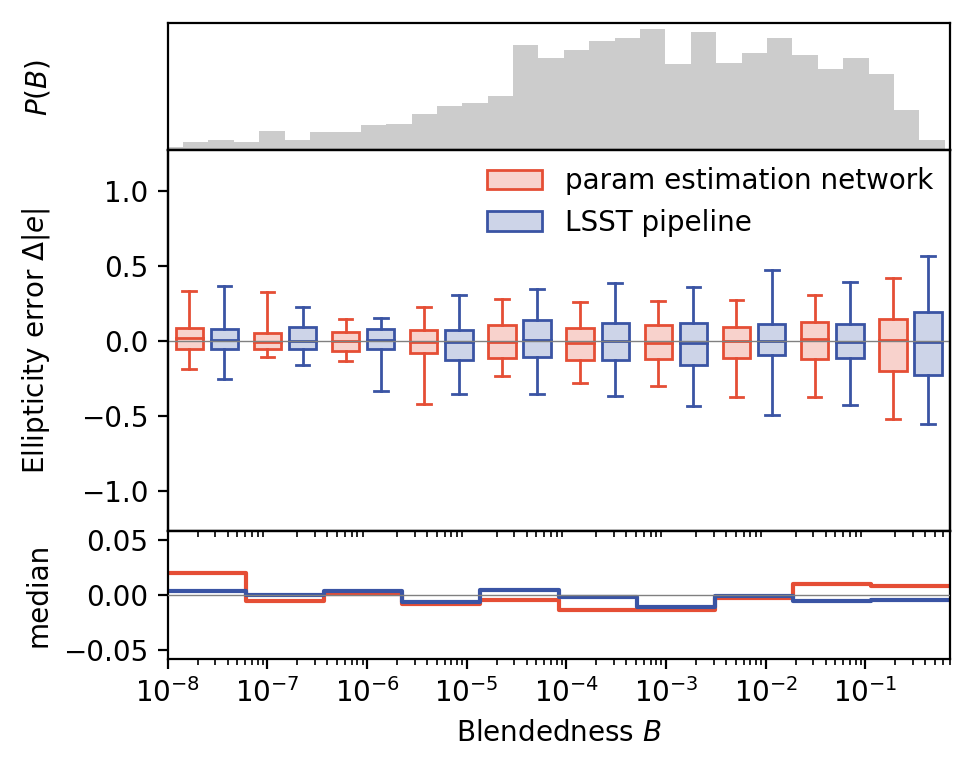

In [26]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e2_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.058, 0.058),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_hsm.pdf')

In [72]:
bin_means

array([-0.00185106,  0.00928741,  0.03036636,  0.0150382 ,  0.02943876,
        0.05810296,  0.03487543,  0.02567924,  0.04590995,  0.0806373 ])

In [73]:
median_shear[10:]

[0.004024401580262349,
 -0.005882842269522947,
 -0.006336402571139585,
 -0.008512038359498333,
 -5.106930256459918e-06,
 0.003997317260373107,
 -0.016090082253837658,
 0.0019226985179023187,
 -0.0024950628193332047,
 0.010974040962531231]

In [74]:
np.max(df['snr_r'])

21154.467495250905

2000
[1 2]
0 1
1 2


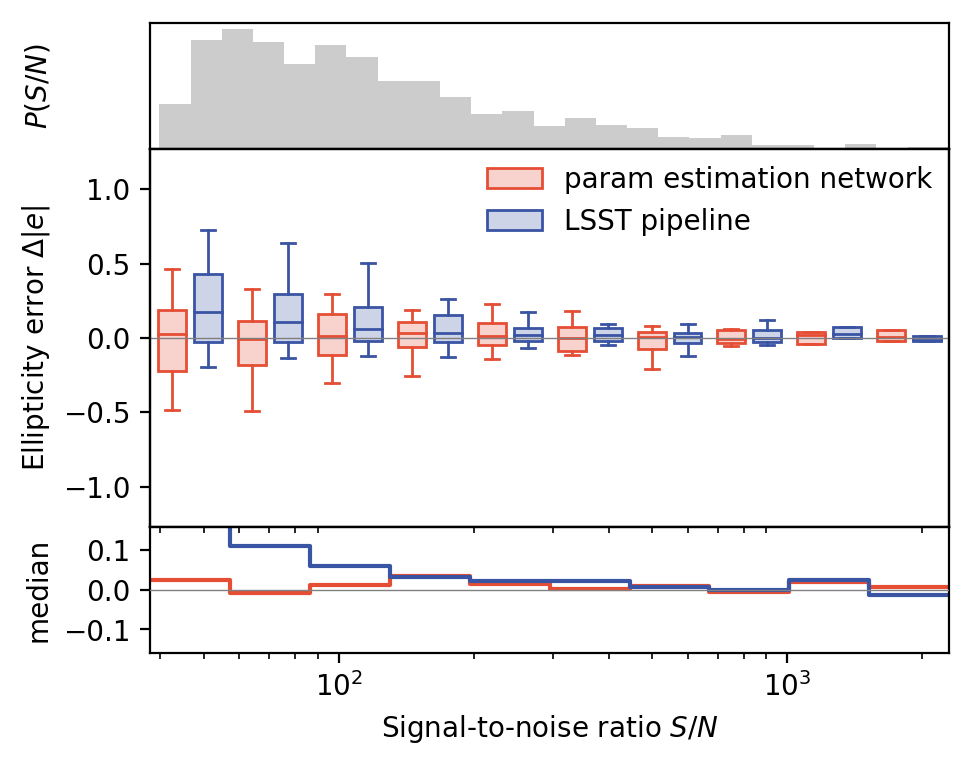

In [25]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

In [ ]:
#np.save('data/net_bnn_noisy.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
np.save('data/net_once_concat_noisy.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))
#np.save('data/net_no_psf_noisy.npy', (e1_out_mean,e2_out_mean,e1_out_std,e2_out_std))

### Load saved results

In [ ]:
e1_out_mean_once_concat, e2_out_mean_once_concat, e1_out_std_once_concat, e2_out_std_once_concat = np.load('data/net_once_concat_noisy.npy')
#e1_out_mean_all_concat, e2_out_mean_all_concat, e1_out_std_all_concat, e2_out_std_all_concat = np.load('data/net_all_concat.npy')
#e1_out_mean_bnn, e2_out_mean_bnn, e1_out_std_bnn, e2_out_std_bnn = np.load('data/net_bnn_noisy.npy')
e1_out_mean_no_psf, e2_out_mean_no_psf, e1_out_std_no_psf, e2_out_std_no_psf = np.load('data/net_no_psf_noisy.npy')
#e1_out_mean_one_concat_dense, e2_out_mean_one_concat_dense, e1_out_std_one_concat_dense, e2_out_std_one_concat_dense = np.load('data/net_one_concat_dense.npy')

In [ ]:
nb_of_points = 1000

Std as function of SNR: how does aleatoric uncertainty react to SNR ?

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(data['snr_r'][:nb_of_points], e1_out_std_once_concat, '.', alpha = 0.3, label = 'with psf')
axes[0].plot(data['snr_r'][:nb_of_points], e1_out_std_no_psf, '.', alpha = 0.3, label = 'without psf')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('SNR')
axes[0].set_ylabel('std $e_1$')
axes[0].set_title('$e_1$')
axes[0].legend()

axes[1].plot(data['snr_r'][:nb_of_points], e2_out_std_once_concat, '.', alpha = 0.3, label = 'with psf')
axes[1].plot(data['snr_r'][:nb_of_points], e2_out_std_no_psf, '.', alpha = 0.3, label = 'without psf')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('SNR')
axes[1].set_ylabel('std $e_2$')
axes[1].set_title('$e_2$')
axes[1].legend()

Models comparison

In [ ]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_no_psf]

labels=['det psf',  'det no psf']

In [ ]:
def compar_models(mean_results_e1, mean_results_e2,e1_out_std,e2_out_std, param, xlim, labels, log = True):
    
    fig, axes = plt.subplots(3,3, figsize = (24,12))

    for i, res in enumerate (mean_results_e1):
        if log:
            bins=np.logspace(np.log10(xlim[0]),np.log10(xlim[1]), 11)

            axes[0,0].set_xscale('log')
            axes[0,1].set_xscale('log')
            axes[0,2].set_xscale('log')
            axes[1,1].set_xscale('log')
            axes[1,0].set_xscale('log')
            axes[1,2].set_xscale('log')
            axes[2,1].set_xscale('log')
            axes[2,0].set_xscale('log')
            axes[2,2].set_xscale('log')
        else:
            bins=np.linspace(xlim[0],xlim[1],11)

        axes[0,0].set_xlim(xlim)
        axes[0,1].set_xlim(xlim)
        axes[0,2].set_xlim(xlim)
        axes[1,1].set_xlim(xlim)
        axes[1,0].set_xlim(xlim)
        axes[1,2].set_xlim(xlim) 
        axes[2,1].set_xlim(xlim)
        axes[2,0].set_xlim(xlim)
        axes[2,2].set_xlim(xlim) 

        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e1[i]+e1[:nb_of_points])/e1_out_std[i], statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e1[i]+e1[:nb_of_points])/e1_out_std[i], statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,0].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,0].legend()
        axes[0,0].set_title('mean $e_1$')
        
        axes[1,0].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,0].set_title('std of means $e_1$')
        
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], std_results_e1[i], statistic='mean', bins=bins)
        axes[2,0].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,0].set_title('mean uncertainty $e_1$')
        
        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e2[i]-e2[:nb_of_points])/e2_out_std[i], statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (mean_results_e2[i]-e2[:nb_of_points])/e2_out_std[i], statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,1].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,1].legend()
        axes[0,1].set_title('mean $e_2$')
        axes[1,1].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,1].set_title('std of means $e_2$')
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], std_results_e2[i], statistic='mean', bins=bins)
        axes[2,1].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,1].set_title('mean uncertainty $e_2$')

        e = np.sqrt(e1[:nb_of_points]**2+e2[:nb_of_points]**2)
        e_out = np.sqrt(mean_results_e1[i]**2+mean_results_e2[i]**2)
        std_sqrt = np.sqrt(std_results_e1[i]**2+std_results_e2[i]**2)
        e_std = np.sqrt(e1_out_std[i]**2+e2_out_std[i]**2)

        bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points],(e_out-e)/e_std, statistic='mean', bins=bins)
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], (e_out-e)/e_std, statistic='std', bins=bins)
        bin_centers = np.zeros(10)
        for k in range(10):
            bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
            
        axes[0,2].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[0,2].hlines(0,xmin = 0,xmax=np.max(data[param]) , color='red', alpha = 0.4)
        axes[0,2].legend()
        axes[0,2].set_title('mean e')
        axes[1,2].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[1,2].set_title('std of means e')
        bin_std, bin_edges, binnumber = scipy.stats.binned_statistic(data[param][:nb_of_points], e_std, statistic='mean', bins=bins)
        axes[2,2].plot(bin_centers,bin_std, marker = '.',linestyle = '-', alpha = 0.2, label = labels[i])
        axes[2,2].set_title('mean uncertainty e')

In [ ]:
e = np.sqrt(e1**2+e2**2)
data['e']=e

In [ ]:
compar_models(mean_results_e1, mean_results_e2,std_results_e1,std_results_e2, 'e', xlim = (0,1), labels=labels, log = False)

In [ ]:
mean_results_e1 = [e1_out_mean_once_concat,]
std_results_e1 = [e1_out_std_once_concat,]

mean_results_e2 = [e2_out_mean_once_concat,]
std_results_e2 = [e2_out_std_once_concat,]

labels=['det network']

In [ ]:
compar_models(mean_results_e1, mean_results_e2,std_results_e1,std_results_e2, 'blendedness', xlim = (0.00001,0.5), labels=labels, log = False)

## Test on images : noisy images

In [ ]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_bnn,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_bnn,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_bnn,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_bnn,e2_out_std_no_psf]

labels=['det one concat', 'BNN', 'det no psf']

In [ ]:
mean_results_e1 = [e1_out_mean_once_concat,e1_out_mean_no_psf]
std_results_e1 = [e1_out_std_once_concat,e1_out_std_no_psf]

mean_results_e2 = [e2_out_mean_once_concat,e2_out_mean_no_psf]
std_results_e2 = [e2_out_std_once_concat,e2_out_std_no_psf]

labels=['det one concat',  'det no psf']

In [ ]:
def gaussian(mean,std):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

In [ ]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
images_noisy = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')

In [ ]:
fig, axes = plt.subplots(10,4, figsize = (20, 40))

x = np.linspace(-1,1, 1000)
for i in range (10):
    axes[i,0].imshow(images_noisy[i,:,:,2])
    axes[i,1].imshow(images[i,:,:,2])
    for k in range(len(labels)):#3
        _ = axes[i,2].plot(x, gaussian(mean_results_e1[k][i], std_results_e1[k][i]), label = labels[k])
        _ = axes[i,3].plot(x, gaussian(mean_results_e2[k][i], std_results_e2[k][i]), label = labels[k])
    axes[i,2].axvline(-e1[i], color = 'r')
    axes[i,3].axvline(e2[i], color = 'r')
    axes[i,2].set_xlim(-e1[i]-0.2,-e1[i]+0.2)
    axes[i,3].set_xlim(e2[i]-0.2,e2[i]+0.2)
    axes[i,2].set_title('$e_1$')
    axes[i,3].set_title('$e_2$')
    axes[i,2].legend()

In [ ]:
fig, axes = plt.subplots(20,4, figsize = (16, 80))

x = np.linspace(-1,1, 1000)
for i in range (20):
    plot.plot_rgb(images_noisy[i], bands = [3,2,1],ax= axes[i,0], band_first= False,zoom = 1)
    #axes[i,0].imshow(images_noisy[i,:,:,2])
    plot.plot_rgb(images[i], bands = [3,2,1],ax= axes[i,1], band_first= False,zoom = 1)
    #axes[i,1].imshow(images[i,:,:,2])
    for k in range(len(labels)):#3
        _ = axes[i,2].plot(x, gaussian(mean_results_e1[k][i], std_results_e1[k][i]), label = labels[k])
        _ = axes[i,3].plot(x, gaussian(mean_results_e2[k][i], std_results_e2[k][i]), label = labels[k])
    axes[i,2].axvline(-e1[i], color = 'r')
    axes[i,3].axvline(e2[i], color = 'r')
    axes[i,2].set_xlim(-e1[i]-0.2,-e1[i]+0.2)
    axes[i,3].set_xlim(e2[i]-0.2,e2[i]+0.2)
    axes[i,2].set_title('$e_1$')
    axes[i,3].set_title('$e_2$')
    axes[i,0].set_title('DC2 image')
    axes[i,1].set_title('Noiseless centered galaxy')
    #axes[i,2].legend()

#### For BNN: Evaluate aleatoric and epistemic uncertainty

In [ ]:
N = 100

image_array = np.zeros((10*N,59,59,6))
psf_array = np.zeros((10*N,59,59,6))

for z in range (N):
    image_array[z*10:(z+1)*10] =  images[:10]
    psf_array[z*10:(z+1)*10] =  psf[:10]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [ ]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn = np.zeros((10,N))
e2_out_mean_bnn = np.zeros((10,N))
e1_out_std_bnn = np.zeros((10,N))
e2_out_std_bnn = np.zeros((10,N))

for i in range (N):
    for k in range (10):
        e1_out_mean_bnn[k,i] = e1_mean[k+i*10]
        e2_out_mean_bnn[k,i] = e2_mean[k+i*10]

        e1_out_std_bnn[k,i] = e1_std[k+i*10]
        e2_out_std_bnn[k,i] = e2_std[k+i*10]

In [ ]:
N = 100

image_array = np.zeros((10*N,59,59,6))
psf_array = np.zeros((10*N,59,59,6))

for z in range (N):
    image_array[z*10:(z+1)*10] =  images_noisy[:10]
    psf_array[z*10:(z+1)*10] =  psf[:10]
    

output_v1 = model_bnn([tf.cast(image_array, tf.float32), tf.cast(psf_array, tf.float32)])

In [ ]:
e1_mean = K.get_value(output_v1.mean())[:,0]
e2_mean = K.get_value(output_v1.mean())[:,1]
e1_std = K.get_value(output_v1.stddev())[:,0]
e2_std = K.get_value(output_v1.stddev())[:,1]


e1_out_mean_bnn_noisy = np.zeros((10,N))
e2_out_mean_bnn_noisy = np.zeros((10,N))
e1_out_std_bnn_noisy = np.zeros((10,N))
e2_out_std_bnn_noisy = np.zeros((10,N))

for i in range (N):
    for k in range (10):
        e1_out_mean_bnn_noisy[k,i] = e1_mean[k+i*10]
        e2_out_mean_bnn_noisy[k,i] = e2_mean[k+i*10]

        e1_out_std_bnn_noisy[k,i] = e1_std[k+i*10]
        e2_out_std_bnn_noisy[k,i] = e2_std[k+i*10]

In [ ]:
np.percentile(K.get_value(output_v1[1,0]),97.5)

In [ ]:
np.percentile(K.get_value(output_v1[1,0]),2.5)

In [ ]:
gal_nb = 6

In [ ]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(e1_out_mean_bnn[gal_nb], bins = 10)
axes[0].axvline(-e1[gal_nb], color = 'r')

_ = axes[1].hist(e1_out_std_bnn[gal_nb], bins = 10)

_ = axes[2].hist(e2_out_mean_bnn[gal_nb], bins = 10)
axes[2].axvline(e2[gal_nb], color = 'r')

_ = axes[3].hist(e2_out_std_bnn[gal_nb], bins = 10)
axes[4].imshow(images[gal_nb,:,:,2])

In [ ]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(e1_out_mean_bnn_noisy[gal_nb], bins = 10)
axes[0].axvline(-e1[gal_nb], color = 'r')

_ = axes[1].hist(e1_out_std_bnn_noisy[gal_nb], bins = 10)

_ = axes[2].hist(e2_out_mean_bnn_noisy[gal_nb], bins = 10)
axes[2].axvline(e2[gal_nb], color = 'r')

_ = axes[3].hist(e2_out_std_bnn_noisy[gal_nb], bins = 10)
axes[4].imshow(images_noisy[gal_nb,:,:,2])

##### Aleatoric and epistemic uncertainties increases with noise and other galaxies on images

In [ ]:
fig, axes = plt.subplots(3,2, figsize = (12,12))

axes[0,0].plot(-e1[:10],e1_out_std_bnn_noisy[:,0], '.', label ="$\sigma^{al}$  - noisy input")
axes[0,0].plot(-e1[:10],e1_out_std_bnn[:,0], '.', label ="$\sigma^{al}$  - noiseless input")
axes[0,0].legend()
axes[0,0].set_xlabel('$e_1$ input')
axes[0,0].set_ylabel('$\sigma_{e_1}$')

axes[0,1].plot(e2[:10],e2_out_std_bnn_noisy[:,0], '.', label ="$\sigma^{al}$  - noisy input")
axes[0,1].plot(e2[:10],e2_out_std_bnn[:,0], '.', label ="$\sigma^{al}$ - noiseless input")
#axes[1].legend()
axes[0,1].set_xlabel('$e_2$ input')
axes[0,1].set_ylabel('$\sigma_{e_2}$')

std_e1_epistemic_noisy=np.zeros((10,))
std_e2_epistemic_noisy=np.zeros((10,))
std_e1_epistemic_noiseless=np.zeros((10,))
std_e2_epistemic_noiseless=np.zeros((10,))
for i in range(10):
    std_e1_epistemic_noisy[i] = np.std(e1_out_std_bnn_noisy[i])
    std_e2_epistemic_noisy[i] = np.std(e2_out_std_bnn_noisy[i])
    std_e1_epistemic_noiseless[i] = np.std(e1_out_std_bnn[i])
    std_e2_epistemic_noiseless[i] = np.std(e2_out_std_bnn[i])
    
axes[1,0].plot(-e1[:10],std_e1_epistemic_noisy, '.', color = 'blue', label ="$\sigma^{ep}$ - noisy input")
axes[1,0].plot(-e1[:10],std_e1_epistemic_noiseless, '.', color = 'orange', label ="$\sigma^{ep}$ - noiseless input")
axes[1,0].legend()
axes[1,0].set_xlabel('$e_1$ input')
axes[1,0].set_ylabel('$\sigma_{e_1}$')

axes[1,1].plot(e2[:10],std_e2_epistemic_noisy, '.',color = 'blue', label ="$\sigma^{ep}$ - noisy input")
axes[1,1].plot(e2[:10],std_e2_epistemic_noiseless, '.',color = 'orange', label ="$\sigma^{ep}$ - noiseless input")
#axes[1].legend()
axes[1,1].set_xlabel('$e_2$ input')
axes[1,1].set_ylabel('$\sigma_{e_2}$')

axes[0,0].set_yscale('log')
axes[0,1].set_yscale('log')
axes[1,0].set_yscale('log')
axes[1,1].set_yscale('log')


axes[2,0].plot(-e1[:10], e1_out_std_bnn_noisy[:,0] - std_e1_epistemic_noisy, '.', label = 'noisy input')
axes[2,0].plot(-e1[:10], e1_out_std_bnn[:,0] - std_e1_epistemic_noiseless, '.', label = 'noiseless input')
axes[2,0].set_xlabel('$e_1$ input')
axes[2,0].set_ylabel('$\sigma^{al}_{e_1}$ - $\sigma^{ep}_{e_1}$')
axes[2,0].legend()

axes[2,1].plot(e2[:10], e2_out_std_bnn_noisy[:,0] - std_e2_epistemic_noisy, '.', label = 'noisy input')
axes[2,1].plot(e2[:10], e2_out_std_bnn[:,0] - std_e2_epistemic_noiseless, '.', label = 'noiseless input')
axes[2,1].set_xlabel('$e_2$ input')
axes[2,1].set_ylabel('$\sigma^{al}_{e_2}$ - $\sigma^{ep}_{e_2}$')


Epistemic uncertainty smaller than aleatoric one here, even when tested on noisy images.

##### Only one case where epistemic uncertainty is higher than aleatoric for the noisy image:

In [ ]:
np.where((e2[:10]<0.3) & (e2[:10]>0.21))

In [ ]:
e1_out_mean_bnn_noisy.shape

In [ ]:
img_nb = 9

In [ ]:
print('e1 is equal to: ' +str(-e1[img_nb])+' and e2 : '+str(e2[img_nb]))
fig, axes = plt.subplots(1,3, figsize = (12,4))
axes[0].imshow(images_noisy[img_nb,:,:,2])

x = np.linspace(-1,1, 1000)

for i in range (100):   
    axes[1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)   
    axes[2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,i], e2_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)

axes[1].plot(x, gaussian(np.mean(e1_out_mean_bnn_noisy[img_nb,:]), np.mean(e1_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)   
axes[2].plot(x, gaussian(np.mean(e2_out_mean_bnn_noisy[img_nb,:]), np.mean(e2_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)
    

axes[1].axvline(-e1[img_nb], color = 'r')
axes[2].axvline(e2[img_nb], color = 'r')
axes[1].set_xlim(-e1[img_nb]-0.2,-e1[img_nb]+0.2)
axes[2].set_xlim(e2[img_nb]-0.2,e2[img_nb]+0.2)
axes[1].set_title('$e_1$')
axes[2].set_title('$e_2$')
axes[1].legend()

Could be understood as a very bright galaxy is on the image, something that the model is troubling to deal with as it did not see this in its training set.

In [ ]:
fig, axes = plt.subplots(10,5, figsize = (25,50))

x = np.linspace(-1,1, 1000)
for img_nb in range (10):
    print('e1 is equal to: ' +str(-e1[img_nb])+' and e2 : '+str(e2[img_nb]))
    axes[img_nb,0].imshow(images_noisy[img_nb,:,:,2])
    for i in range (100):   
         
        axes[img_nb,2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,i], e2_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)
        axes[img_nb,3].plot(x, gaussian(e1_out_mean_bnn[img_nb,i], e1_out_std_bnn[img_nb,i]), color = 'grey', alpha = 0.1)   
        axes[img_nb,4].plot(x, gaussian(e2_out_mean_bnn[img_nb,i], e2_out_std_bnn[img_nb,i]), color = 'grey', alpha = 0.1)
        if i == 99:
            axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1, label = 'one sample')  
        else:
            axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,i], e1_out_std_bnn_noisy[img_nb,i]), color = 'grey', alpha = 0.1)  

    axes[img_nb,1].plot(x, gaussian(np.mean(e1_out_mean_bnn_noisy[img_nb,:]), np.mean(e1_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1, label = 'mean of samples')   
    axes[img_nb,2].plot(x, gaussian(np.mean(e2_out_mean_bnn_noisy[img_nb,:]), np.mean(e2_out_std_bnn_noisy[img_nb,:])), color = 'black', alpha = 1)
    axes[img_nb,3].plot(x, gaussian(np.mean(e1_out_mean_bnn[img_nb,:]), np.mean(e1_out_std_bnn[img_nb,:])), color = 'black', alpha = 1)   
    axes[img_nb,4].plot(x, gaussian(np.mean(e2_out_mean_bnn[img_nb,:]), np.mean(e2_out_std_bnn[img_nb,:])), color = 'black', alpha = 1)
    
    axes[img_nb,1].plot(x, gaussian(e1_out_mean_bnn_noisy[img_nb,0], e1_out_std_bnn_noisy[img_nb,0]), color = 'red', alpha = 0.5, label = 'first sample')   
    axes[img_nb,2].plot(x, gaussian(e2_out_mean_bnn_noisy[img_nb,0], e2_out_std_bnn_noisy[img_nb,0]), color = 'red', alpha = 0.5)
    axes[img_nb,3].plot(x, gaussian(e1_out_mean_bnn[img_nb,0], e1_out_std_bnn[img_nb,0]), color = 'red', alpha = 0.5)   
    axes[img_nb,4].plot(x, gaussian(e2_out_mean_bnn[img_nb,0], e2_out_std_bnn[img_nb,0]), color = 'red', alpha = 0.5)


    axes[img_nb,1].axvline(-e1[img_nb], color = 'r')
    axes[img_nb,2].axvline(e2[img_nb], color = 'r')
    axes[img_nb,1].set_xlim(-e1[img_nb]-0.5,-e1[img_nb]+0.5)
    axes[img_nb,2].set_xlim(e2[img_nb]-0.5,e2[img_nb]+0.5)
    axes[img_nb,1].set_title('$e_1$ noisy')
    axes[img_nb,2].set_title('$e_2$ noisy')
    axes[img_nb,1].legend()
    
    axes[img_nb,3].axvline(-e1[img_nb], color = 'r')
    axes[img_nb,4].axvline(e2[img_nb], color = 'r')
    axes[img_nb,3].set_xlim(-e1[img_nb]-0.2,-e1[img_nb]+0.2)
    axes[img_nb,4].set_xlim(e2[img_nb]-0.2,e2[img_nb]+0.2)
    axes[img_nb,3].set_title('$e_1$ noiseless')
    axes[img_nb,4].set_title('$e_2$ noiseless')
    
    
    axes[img_nb,1].set_ylim(-0.1,80)
    axes[img_nb,2].set_ylim(-0.1,80)
    axes[img_nb,3].set_ylim(-0.1,80)
    axes[img_nb,4].set_ylim(-0.1,80)

In [ ]:
print(np.mean(-e1[:1000]), np.mean(e1_out_mean_bnn))
print(np.mean(e2[:1000]), np.mean(e2_out_mean_bnn))

In [ ]:
np.average(e1_out_mean_no_psf, weights=1/e1_out_std_no_psf)

In [ ]:
np.average(e2_out_mean_no_psf, weights=1/e2_out_std_no_psf)

## Shear bias estimation

In [ ]:
def boxplot_func_shear_bias(df_in, x,ell, y, z,shear,
            xlim, ylim, ylim2, 
            x_scale, 
            legend,
            x_label, y_label, y_label_hist, y_label_2,
            errors = None,
            legend_remove = False,
            palette = ["#3498db","#e74c3c"],
            nbins = 11):
    
    m = []
    c = []
    err = []
    
    import matplotlib as mpl
    mpl.rcdefaults()
    
    if errors is not None:
        df_plot = df_in.drop(errors)
    else:
        df_plot = df_in

    df_plot = df_plot.dropna()
    print(len(df_plot))
    if x_scale == 'log':
        x_bins = np.geomspace(xlim[0], xlim[1], nbins+1)
    else :
        x_bins = np.linspace(xlim[0], xlim[1], nbins+1)
    
    x_bins[0] -= 1e-5
    x_bins[-1] += 1e-5
    
    idx = np.digitize(df_plot[x], x_bins)
    
    fig, axes = plt.subplots(3,1, figsize=(5,4), gridspec_kw={'height_ratios': [1, 3,2]})
    
    if x_scale == 'log':
        sns.distplot(np.log10(df_plot[x]), ax=axes[0], color='0.8')
        axes[0].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
    else:
        sns.distplot(df_plot[x], ax=axes[0], color='0.8')
        axes[0].set_xlim(xlim[0], xlim[1])
    
    axes[0].set_yticks([])
    axes[0].set_ylabel(y_label_hist)
    axes[0].set_xticks([])
#####
    print(idx, len(idx))
    exp = np.unique(df_plot[z])
    N_exp = len(exp)
    handles = []
    for ik, key in enumerate(exp):
        stats = {}
        for i in range(1,len(x_bins)):
            xx = df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values+df_plot[shear][np.logical_and(idx==i,df_plot[z]==key)].values
            yy = df_plot[y][np.logical_and(idx==i,df_plot[z]==key)].values
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(xx,yy)

            m.append(slope-1)
            c.append(intercept)
            err.append(std_err)
        handles = exp
        #plt.setp(key, color=palette[ik])
#####        
    
    ax = axes[1]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(m).reshape(N_exp,int(len(m)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    #ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim)
    ax.set_ylabel(y_label)
    ax.xaxis.tick_bottom()
    if not legend_remove:
        ax.legend(handles, legend, frameon=False, loc ='upper right', borderpad = 0.1, fontsize = 10)
           
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    
    ax = axes[2]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(c).reshape(N_exp,int(len(c)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim2)
    ax.set_ylabel(y_label_2)
    ax.xaxis.tick_bottom()
            
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    return fig , m,c,err

Shear bias: $i = 1,2$


$〈\epsilon_{i,obs}〉=g_{i,obs}=c_i+(1+m_i)g_i$


$g_{i,obs}=c_i+(1+m_i)(〈\epsilon_{i,int}〉+g_i)$

source (https://hal-cea.archives-ouvertes.fr/cea-02949701/document)

or $1+m_i=〈R_{ii}〉$ 

with $ R_{αβ} ≈ \frac{e_{obs,+α}−e_{obs,−α}}{2∆g_β}$ , source (https://www.aanda.org/articles/aa/pdf/2019/01/aa33740-18.pdf)

In [ ]:
df_v1 = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

In [ ]:
df_v1.info()

In [ ]:
df_v2 = df_v1[(np.abs(df_v1['e1'])<=0.1)]

df_v2.info()

In [ ]:
df_v2.index

In [ ]:
df_v1['e1'][2]

In [ ]:
df_v1['e1'][1]

In [ ]:
df_v2['e1'][1]

In [ ]:
df_v2['e1'][4], df_v1['e1'][4]

In [ ]:
df_v2['e1'][2]

In [ ]:
df_plot_hsm = pd.DataFrame()

df_v1 = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')


e_hsm = np.sqrt(-data['e1_hsm_regauss'][:nb_of_points]**2 + data['e2_hsm_regauss'][:nb_of_points]**2)

e = np.sqrt(e1**2+e2**2)
e_out = np.sqrt(e1_out_mean**2+e2_out_mean**2)

df_plot_hsm = pd.concat([df_v1[:nb_of_points], df_v1[:nb_of_points]], ignore_index=True, sort = True)
df_plot_hsm['e_error']=np.concatenate([e_out - e[:nb_of_points], e_hsm-e[:nb_of_points]])
df_plot_hsm['e']=np.concatenate([e[:nb_of_points],e[:nb_of_points]])

df_plot_hsm['exp'] = [1]*nb_of_points + [2]*nb_of_points

In [ ]:
df_plot_hsm['e1_meas']= np.concatenate([e1_out_mean, data['e1_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e2_meas']= np.concatenate([e2_out_mean, data['e2_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e1_sheared'] = np.concatenate([-e1[:nb_of_points],-e1[:nb_of_points]])
df_plot_hsm['e2_sheared'] = np.concatenate([e2[:nb_of_points],e2[:nb_of_points]])

In [ ]:
ellipticity = calc_lensed_ellipticity(-df_plot_hsm['e1'].values, df_plot_hsm['e2'].values, 0,0, 0)

In [ ]:
df_plot_hsm['e1_conv'] = ellipticity_conversion(df_plot_hsm['e1'])
df_plot_hsm['e2_conv'] = ellipticity_conversion(df_plot_hsm['e2'])

In [ ]:
np.min(df_plot_hsm['snr_r'])

In [ ]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (40, 500),
              ylim = (-0.1,0.1), 
              ylim2 = (-0.05, 0.05), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.35]),
              nbins = 10)

In [ ]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e2_conv', y = 'e2_meas', z = 'exp', shear = 'shear_2',
              xlim = (50, 500),
              ylim = (-0.65,1.6), 
              ylim2 = (-0.115, 0.115), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_2$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_2$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,.35]),#0.35,
              nbins = 10)

In [ ]:
df_plot_hsm_2 = df_plot_hsm[(df_plot_hsm['blendedness']>0.0000001)]

In [ ]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm_2, 
              x = 'blendedness', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (0.00001, 1),
              ylim = (-0.1,0.1), 
              ylim2 = (-0.1, 0.1), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

In [ ]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'e1_conv', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (-0.75, 0.75),
              ylim = (-1.76,1.76), 
              ylim2 = (-0.315, 0.315), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)